<h1>Normalization</h1>

<h3>Min - Max Scaling</h3>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('wine_data.csv' , usecols = [0,1,2])

In [3]:
df.sample(5)

,class_label,alcohol,malic_acid
143,3,13.62,4.95
108,2,12.22,1.29
22,1,13.71,1.86
37,1,13.05,1.65
74,2,11.96,1.09


In [4]:
df.describe()

,class_label,alcohol,malic_acid
count,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348
std,0.775035,0.811827,1.117146
min,1.000000,11.030000,0.740000
25%,1.000000,12.362500,1.602500
50%,2.000000,13.050000,1.865000
75%,3.000000,13.677500,3.082500
max,3.000000,14.830000,5.800000


In [5]:
import seaborn as sns

<Axes: xlabel='alcohol', ylabel='Density'>

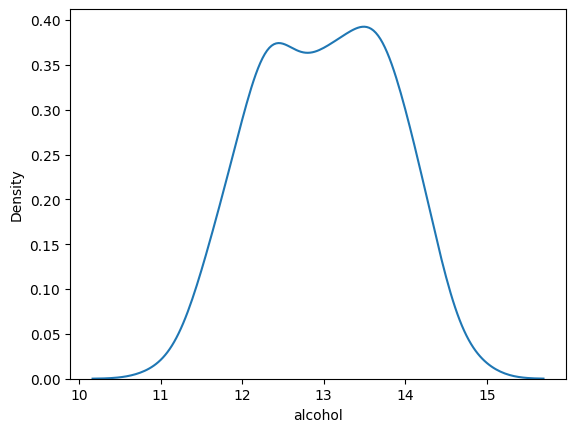

In [6]:
sns.kdeplot(df['alcohol'])

<Axes: xlabel='malic_acid', ylabel='Density'>

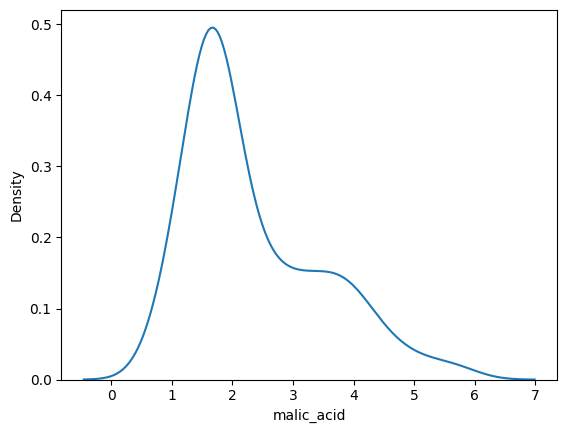

In [7]:
sns.kdeplot(df['malic_acid'])

<Axes: xlabel='alcohol', ylabel='malic_acid'>

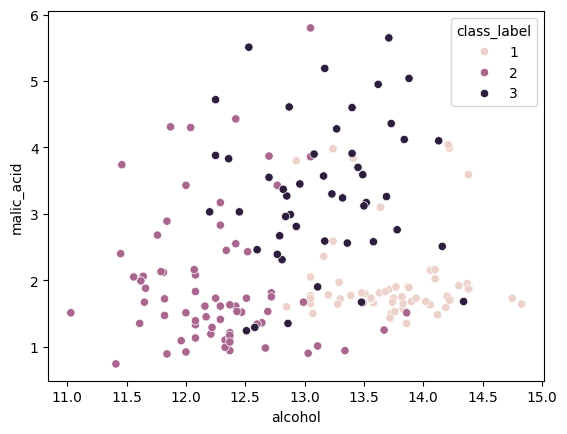

In [8]:
sns.scatterplot(data = df, x = 'alcohol', y = 'malic_acid', hue= 'class_label')

<Axes: xlabel='alcohol', ylabel='malic_acid'>

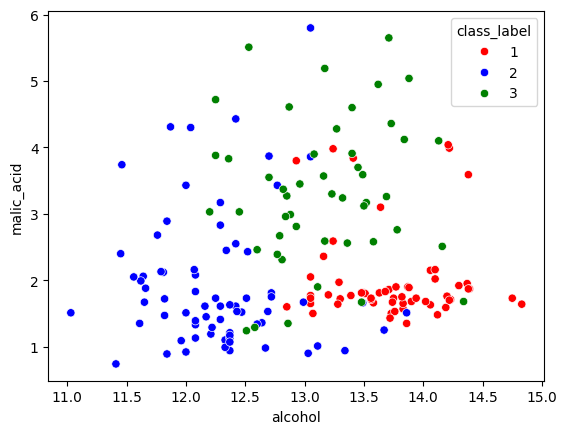

In [9]:
color_dict = {1: 'red', 2: 'blue', 3: 'green'}

sns.scatterplot(data = df, x = 'alcohol', y = 'malic_acid', hue= 'class_label', palette = color_dict)

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('class_label', axis=1),
                                                    df['class_label'],
                                                    test_size=0.3,
                                                    random_state=0)

In [11]:
X_train.shape, X_test.shape

((124, 2), (54, 2))

In [12]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
scaler = MinMaxScaler()

In [14]:
scaler.fit(X_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [15]:
import numpy as np

In [16]:
X_train_scaled = scaler.transform(X_train)

In [17]:
X_test_scaled = scaler.transform(X_test)

In [18]:
X_test_scaled

array([[ 0.72849462,  0.16386555],
       [ 0.47311828,  0.37394958],
       [ 0.36021505,  0.05042017],
       [ 0.68010753,  0.17647059],
       [ 0.54301075,  1.03151261],
       [ 0.14247312,  0.24369748],
       [ 0.81451613,  0.26470588],
       [ 0.35752688,  0.61764706],
       [ 0.32795699,  0.17647059],
       [ 0.28225806,  0.19747899],
       [ 0.62634409,  0.35084034],
       [ 0.76612903,  0.87184874],
       [ 0.85215054,  0.18277311],
       [ 0.36021505,  0.03781513],
       [ 0.68548387,  0.35504202],
       [ 0.26075269,  0.00630252],
       [ 0.73387097,  0.13445378],
       [ 0.84946237,  0.14705882],
       [ 0.4327957 ,  0.0987395 ],
       [ 0.75268817,  0.15966387],
       [ 0.55913978,  0.02521008],
       [ 0.54301075,  0.15966387],
       [ 0.59408602,  0.35714286],
       [ 0.39784946,  0.17647059],
       [ 0.34946237,  0.04411765],
       [ 0.40053763,  0.32352941],
       [ 0.37634409,  0.13445378],
       [ 0.30376344,  0.1512605 ],
       [ 0.19623656,

In [19]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [20]:
X_train_scaled.head()

,alcohol,malic_acid
0,0.720430,0.203782
1,0.319892,0.084034
2,0.602151,0.712185
3,0.572581,0.563025
4,0.760753,0.130252


In [21]:
X_test_scaled = pd.DataFrame(X_test_scaled)

In [22]:
X_test_scaled

,alcohol,malic_acid
0,0.728495,0.163866
1,0.473118,0.373950
2,0.360215,0.050420
3,0.680108,0.176471
4,0.543011,1.031513
5,0.142473,0.243697
6,0.814516,0.264706
7,0.357527,0.617647
8,0.327957,0.176471
9,0.282258,0.197479


In [23]:
X_train_scaled.describe()

,alcohol,malic_acid
count,124.000000,124.000000
mean,0.525017,0.313805
std,0.215414,0.238802
min,0.000000,0.000000
25%,0.358199,0.150735
50%,0.540323,0.209034
75%,0.701613,0.495273
max,1.000000,1.000000


In [24]:
X_test_scaled.describe()

,alcohol,malic_acid
count,54.000000,54.000000
mean,0.540571,0.281007
std,0.226251,0.225487
min,0.102151,-0.031513
25%,0.358199,0.148109
50%,0.543011,0.184874
75%,0.723118,0.375525
max,1.021505,1.031513


In [25]:
import matplotlib.pyplot as plt

In [26]:
X_train_scaled = pd.DataFrame(X_train_scaled)

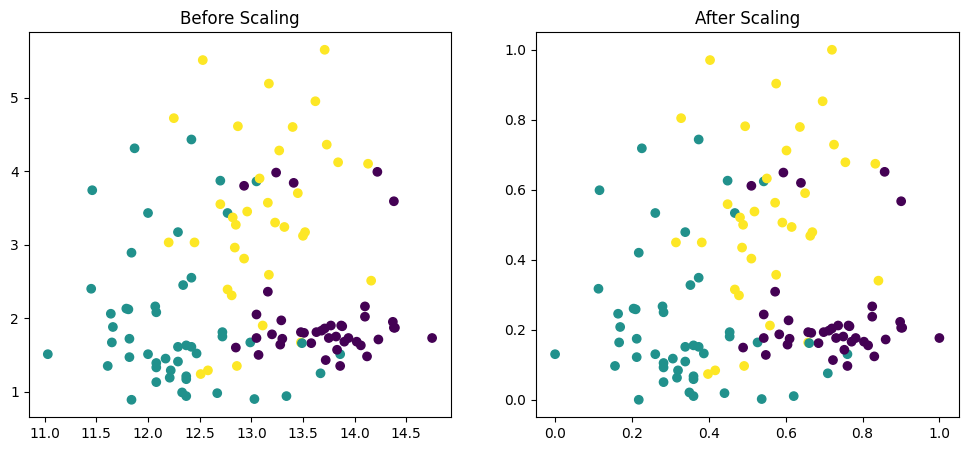

In [28]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['alcohol'], X_train['malic_acid'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['alcohol'], X_train_scaled['malic_acid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

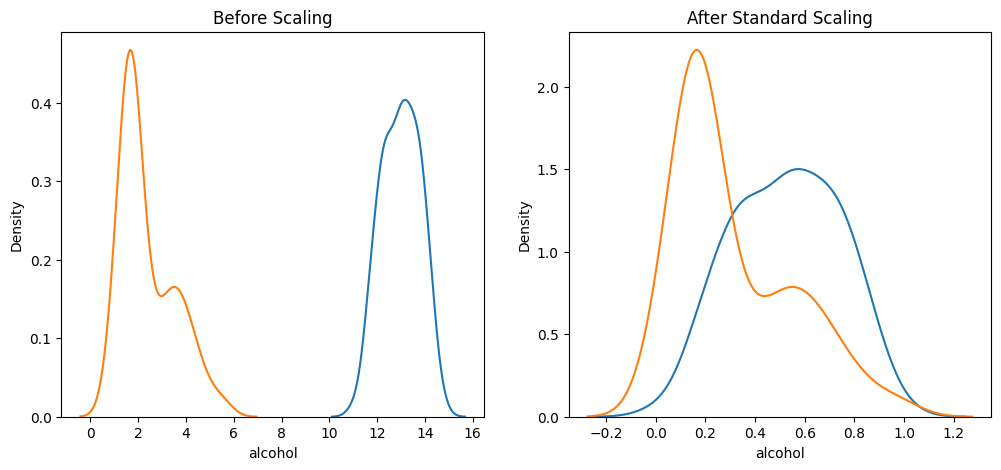

In [30]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title('Before Scaling')
sns.kdeplot(X_train['alcohol'], ax=ax1)
sns.kdeplot(X_train['malic_acid'], ax=ax1)

ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['malic_acid'], ax=ax2)
plt.show()

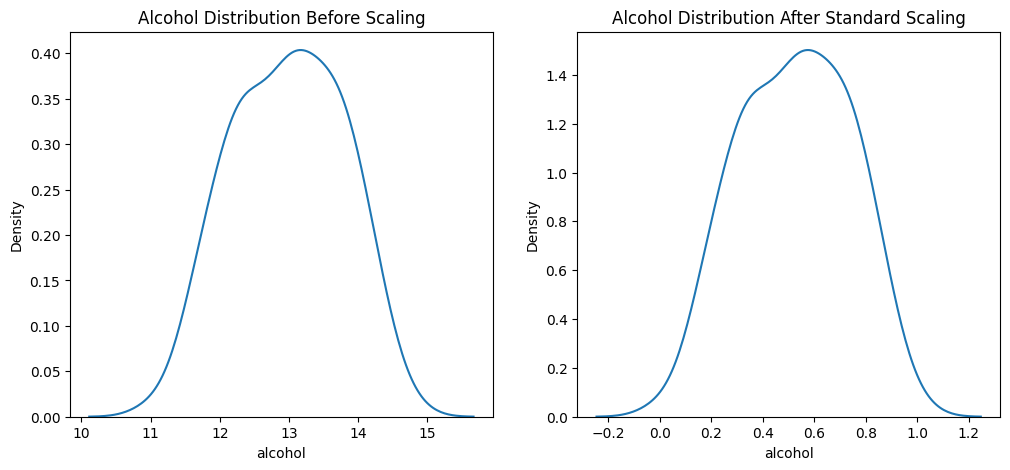

In [32]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['alcohol'], ax=ax1)

ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['alcohol'], ax=ax2)
plt.show()

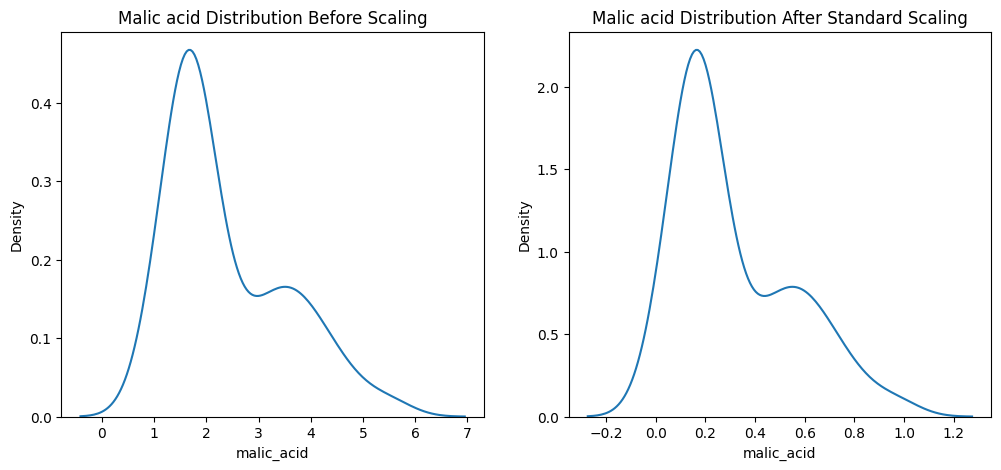

In [34]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['malic_acid'], ax=ax1)

ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['malic_acid'], ax=ax2)
plt.show()

In [35]:
# standardization makes mean = 0 and sd = 1 

In [36]:
# where as the normalization just make chnages in the ranges 

In [37]:
from sklearn.preprocessing import MaxAbsScaler

In [38]:
scalr = MaxAbsScaler()

In [39]:
dataset = pd.read_csv('Social_Network_Ads.csv')

In [40]:
dataset.sample(5)

,Age,EstimatedSalary,Purchased
364,42,104000,1
335,36,54000,0
246,35,50000,0
151,41,45000,0
377,42,53000,0


In [43]:
a_train, a_test, b_train, b_test = train_test_split(dataset.drop('Purchased', axis=1),
                                                    dataset['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

<h3>Max Abstract Scaling</h3>

In [46]:
scalr.fit(a_train)

,copy,True


In [49]:
a_train_scaled = scalr.transform(a_train)
a_test_scaled = scalr.transform(a_test)

In [52]:
a_train_scaled = pd.DataFrame(a_train_scaled)
a_test_scaled = pd.DataFrame(a_test_scaled)

In [54]:
a_train_scaled.describe()

,0,1
count,280.000000,280.000000
mean,0.631071,0.465381
std,0.170303,0.230941
min,0.300000,0.100000
25%,0.500000,0.286667
50%,0.616667,0.470000
75%,0.766667,0.586667
max,1.000000,1.000000


<h3>Robust Scaling</h3>

In [55]:
from sklearn.preprocessing import RobustScaler

In [56]:
sclr = RobustScaler()

In [57]:
dataset_1 = pd.read_csv('Social_Network_Ads.csv')

In [58]:
dataset_1.sample(5)

,Age,EstimatedSalary,Purchased
350,38,113000,1
49,31,89000,0
193,19,70000,0
246,35,50000,0
309,38,50000,0


In [59]:
d_train, d_test, e_train, e_test = train_test_split(dataset_1.drop('Purchased', axis=1),
                                                    dataset_1['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

In [60]:
sclr.fit(d_train)

,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False


In [61]:
d_train_scaled = sclr.transform(d_train)

In [64]:
d_test_scaler = sclr.transform(d_test)

In [66]:
d_train_scaled = pd.DataFrame(d_train_scaled)
d_test_scaled = pd.DataFrame(d_test_scaler)

In [67]:
d_train_scaled.describe()

,0,1
count,280.000000,280.000000
mean,0.054018,-0.015397
std,0.638638,0.769804
min,-1.187500,-1.233333
25%,-0.437500,-0.611111
50%,0.000000,0.000000
75%,0.562500,0.388889
max,1.437500,1.766667
